In [1]:
# Cell 0 — Setup: install Plotly (for interactive) and import libs
try:
    import plotly.express as px
except Exception:
    !pip install -q plotly

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Seaborn style
sns.set(style="whitegrid")

print("✅ Libraries ready.")


✅ Libraries ready.


In [2]:
# Cell 1 — Upload & Load the US Cars dataset from your computer
from google.colab import files

uploaded = files.upload()  # pick your local file, e.g. "USA_cars_datasets.csv"
filename = list(uploaded.keys())[0]

# Try to read CSV (fallback encodings just in case)
try:
    df = pd.read_csv(filename)
except UnicodeDecodeError:
    try:
        df = pd.read_csv(filename, encoding="latin-1")
    except Exception:
        df = pd.read_csv(filename, encoding="cp1252")

print("✅ Dataset loaded:", filename, "-> shape:", df.shape)
df.head()


Saving USA_cars_datasets.csv to USA_cars_datasets.csv
✅ Dataset loaded: USA_cars_datasets.csv -> shape: (2499, 13)


,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [3]:
# Cell 2 — Clean column names, coerce numerics, standardize schema

# Normalize columns (lowercase, underscores, strip)
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
              .str.replace(r"_+", "_", regex=True)
              .str.strip("_")
)

# Build a column mapping to standard names
col_map_candidates = {
    "price": ["price", "selling_price"],
    "year": ["years", "year", "registration_year", "model_year"],
    "brand": ["brand", "make"],
    "model": ["model", "car_model"],
    "color": ["color", "exterior_color"],
    "location": ["state_city", "state", "city", "location"],
    "mileage": ["mileage", "miles", "odometer"],
    "vin": ["vin", "vehicle_identification_number"],
    "title_status": ["title_status", "title", "title_state"],
    "lot": ["lot", "lot_number"],
    "condition": ["condition", "vehicle_condition", "car_condition"]
}

# Resolve columns dynamically
resolved = {}
for std, candidates in col_map_candidates.items():
    for cand in candidates:
        if cand in df.columns:
            resolved[std] = cand
            break

# Helper to fetch a column safely
def col(std_name, default=None):
    return resolved.get(std_name, default)

# Create standardized view (without dropping originals)
# Numeric coercion for price/mileage (strip non-digits)
if col("price"):
    df["price_num"] = (
        df[col("price")]
        .astype(str)
        .str.replace(r"[^\d.]", "", regex=True)
        .replace("", np.nan)
        .astype(float)
    )
if col("mileage"):
    df["mileage_num"] = (
        df[col("mileage")]
        .astype(str)
        .str.replace(r"[^\d.]", "", regex=True)
        .replace("", np.nan)
        .astype(float)
    )

# Year as int where possible
if col("year"):
    df["year_num"] = pd.to_numeric(df[col("year")], errors="coerce").astype("Int64")

# Keep a clean working copy with essential fields
keep_cols = ["price_num", "mileage_num", "year_num",
             col("brand") or "brand",
             col("model") or "model",
             col("condition") or "condition",
             col("location") or "location",
             col("color") or "color",
             col("vin") or "vin",
             col("title_status") or "title_status",
             col("lot") or "lot"]

# Remove any duplicates in keep_cols and drop missing
keep_cols = [c for c in keep_cols if c in df.columns]
df_clean = df[keep_cols].copy()

# Basic sanity filter: drop rows with missing or non-positive price/mileage
if "price_num" in df_clean:
    df_clean = df_clean[df_clean["price_num"].notna() & (df_clean["price_num"] > 0)]
if "mileage_num" in df_clean:
    df_clean = df_clean[df_clean["mileage_num"].notna() & (df_clean["mileage_num"] >= 0)]

print("✅ Clean shape:", df_clean.shape)
df_clean.head()


✅ Clean shape: (2456, 11)


,price_num,mileage_num,year_num,brand,model,condition,state,color,vin,title_status,lot
0,6300.0,274117.0,2008,toyota,cruiser,10 days left,new jersey,black,jtezu11f88k007763,clean vehicle,159348797
1,2899.0,190552.0,2011,ford,se,6 days left,tennessee,silver,2fmdk3gc4bbb02217,clean vehicle,166951262
2,5350.0,39590.0,2018,dodge,mpv,2 days left,georgia,silver,3c4pdcgg5jt346413,clean vehicle,167655728
3,25000.0,64146.0,2014,ford,door,22 hours left,virginia,blue,1ftfw1et4efc23745,clean vehicle,167753855
4,27700.0,6654.0,2018,chevrolet,1500,22 hours left,florida,red,3gcpcrec2jg473991,clean vehicle,167763266


In [4]:
# Cell 3 — EDA summary
print("Missing values per column:")
print(df_clean.isnull().sum().sort_values(ascending=False))

print("\nSummary statistics (numeric):")
display(df_clean.describe(include="all").transpose().head(15))


Missing values per column:
price_num       0
mileage_num     0
year_num        0
brand           0
model           0
condition       0
state           0
color           0
vin             0
title_status    0
lot             0
dtype: int64

Summary statistics (numeric):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price_num,2456.0,NaN,NaN,NaN,19096.25855,11962.176006,25.0,10500.0,17050.0,25800.0,84900.0
mileage_num,2456.0,NaN,NaN,NaN,50111.425081,54604.463791,0.0,21276.75,35048.5,60050.75,1017936.0
year_num,2456.0,<NA>,<NA>,<NA>,2016.931189,2.957497,1973.0,2016.0,2018.0,2019.0,2020.0
brand,2456,28,ford,1217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,2456,126,door,620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,2456,47,2 days left,823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,2456,43,pennsylvania,298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,2456,47,white,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vin,2456,2453,3gcrkse37ag234620,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title_status,2456,2,clean vehicle,2334,NaN,NaN,NaN,NaN,NaN,NaN,NaN


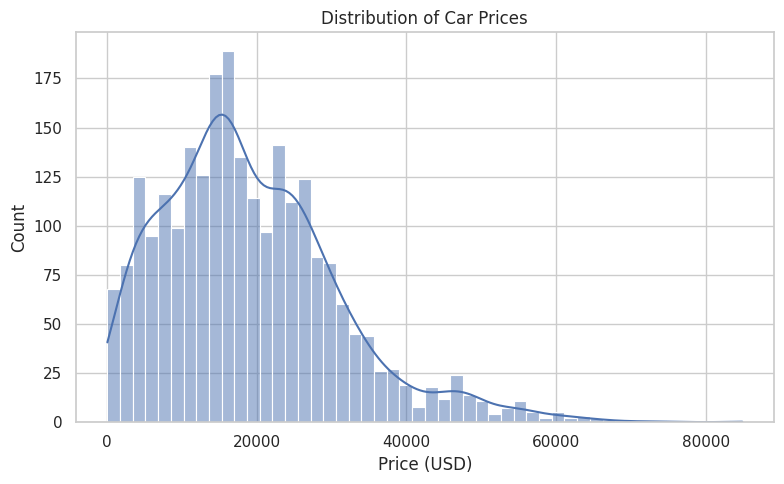

In [5]:
# Cell 4 — Histogram: distribution of car prices
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x="price_num", bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: log-scale version (uncomment if needed)
# plt.figure(figsize=(8,5))
# sns.histplot(data=df_clean, x="price_num", bins=60)
# plt.xscale("log")
# plt.title("Distribution of Car Prices (Log Scale)")
# plt.xlabel("Price (USD, log scale)")
# plt.ylabel("Count")
# plt.tight_layout()
# plt.show()


/tmp/ipython-input-499888881.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_clean[df[brand_col].astype(str).str.strip().isin(top10)].copy()


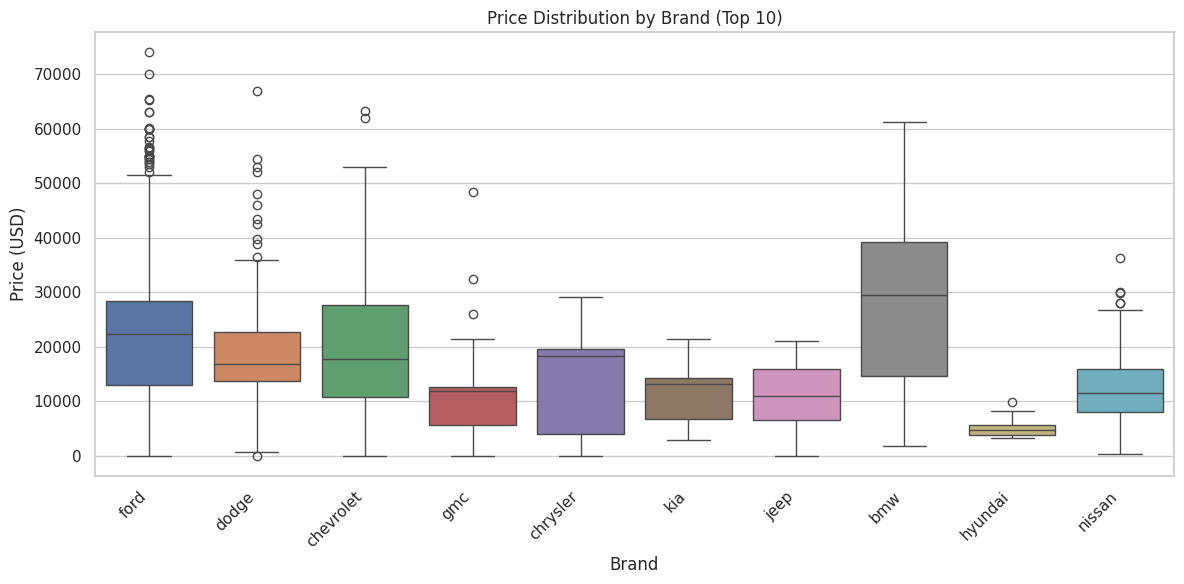

In [6]:
# Cell 5 — Boxplot: price by brand (top 10 by frequency)
brand_col = col("brand") or "brand"
assert brand_col in df.columns or brand_col in df_clean.columns, "Brand column not found."

# Work out top 10 brands by count
top10 = (
    df.assign(_brand=df[brand_col].astype(str).str.strip())
      .query("price_num > 0")
      .groupby("_brand")["price_num"].size()
      .sort_values(ascending=False)
      .head(10)
      .index.tolist()
)

subset = df_clean[df[brand_col].astype(str).str.strip().isin(top10)].copy()
# Order brands by median price (makes the plot easier to read)
order = (
    subset.assign(_brand=df[brand_col].astype(str).str.strip())
          .groupby("_brand")["price_num"].median()
          .sort_values(ascending=False)
          .index.tolist()
)

plt.figure(figsize=(12,6))
sns.boxplot(
    data=subset.assign(_brand=df[brand_col].astype(str).str.strip()),
    x="_brand", y="price_num", hue="_brand", legend=False
)
plt.xticks(rotation=45, ha="right")
plt.title("Price Distribution by Brand (Top 10)")
plt.xlabel("Brand")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()


In [7]:
# Cell 6 — Interactive scatter: Price vs Mileage, color-coded by Condition
cond_col = col("condition") or "condition"
model_col = col("model") or "model"
loc_col   = col("location") or "location"

# Build a robust DataFrame for plotting
plot_df = df_clean.copy()
if cond_col not in plot_df.columns and cond_col in df.columns:
    plot_df[cond_col] = df[cond_col]

if model_col not in plot_df.columns and model_col in df.columns:
    plot_df[model_col] = df[model_col]

if loc_col not in plot_df.columns and loc_col in df.columns:
    plot_df[loc_col] = df[loc_col]

fig = px.scatter(
    plot_df,
    x="mileage_num",
    y="price_num",
    color=cond_col if cond_col in plot_df.columns else None,
    hover_data={
        (model_col if model_col in plot_df.columns else "price_num"): True,
        (loc_col if loc_col in plot_df.columns else "mileage_num"): True,
        "mileage_num": True,
        "price_num": True
    },
    title="Price vs. Mileage (colored by Condition)"
)
fig.update_layout(xaxis_title="Mileage", yaxis_title="Price (USD)")
fig.show()


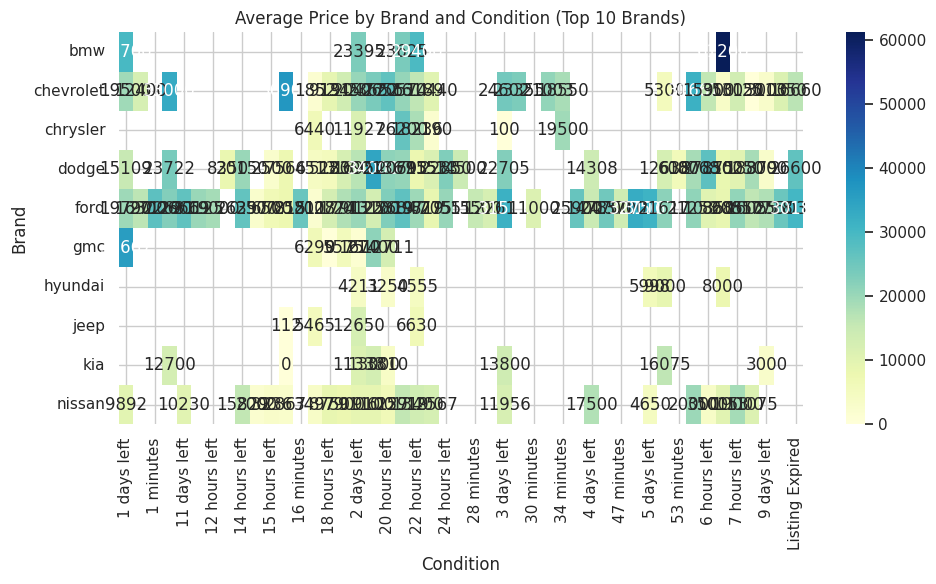

In [8]:
# Cell 7 — Optional heatmap: average price by brand & condition (Top 10 brands)
if cond_col in df.columns or cond_col in df_clean.columns:
    # Use same top10 brands as above
    heat_df = df.copy()
    heat_df["_brand"] = heat_df[brand_col].astype(str).str.strip()
    heat_df = heat_df[heat_df["_brand"].isin(top10)]
    heat_df["_condition"] = heat_df[cond_col].astype(str).str.strip() if cond_col in heat_df.columns else "Unknown"
    heat_df = heat_df[["price_num", "_brand", "_condition"]].dropna(subset=["price_num"])

    pivot = heat_df.pivot_table(values="price_num", index="_brand", columns="_condition", aggfunc="mean")
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title("Average Price by Brand and Condition (Top 10 Brands)")
    plt.xlabel("Condition")
    plt.ylabel("Brand")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 'condition' column not found — skipping heatmap.")


In [9]:
# Cell 8 — Insights
print("""
Insights:
- Price distribution is right-skewed; a log-scale view can help identify structure in the tail.
- Top brands show distinct price medians (boxplots) — luxury brands have higher medians with wider spread.
- Price vs Mileage negative relationship is visible; high-mileage cars tend to be cheaper.
- Condition separates the scatter: better condition clusters at higher prices for comparable mileage.
- (Optional) Heatmap shows how average price varies by brand/condition — useful for pricing heuristics.
""")



Insights:
- Price distribution is right-skewed; a log-scale view can help identify structure in the tail.
- Top brands show distinct price medians (boxplots) — luxury brands have higher medians with wider spread.
- Price vs Mileage negative relationship is visible; high-mileage cars tend to be cheaper.
- Condition separates the scatter: better condition clusters at higher prices for comparable mileage.
- (Optional) Heatmap shows how average price varies by brand/condition — useful for pricing heuristics.

